In [1]:
import json
import random
import ssl
from os import listdir
from os.path import isdir, join
from pathlib import Path

import torch
from torch import nn, optim
from torch.utils.data import random_split, DataLoader
from torchvision.transforms import Compose, ToTensor, Normalize, Resize

from src.helpers import plot_img, visual_exploration
from src.training import training_loop

ssl._create_default_https_context = ssl._create_unverified_context

from torchvision.datasets import OxfordIIITPet


Using device: MPS (Apple Silicon GPU)


In [2]:
with open("../configs/base_config.json", encoding="utf-8") as file:
    config_json = json.load(file)

seed = int(config_json["seed"])

batch_size = int(config_json["data"]["batch_size"])
augmentation = config_json["data"]["augmentation"]

model = config_json["model"]["name"]
dropout = config_json["model"]["dropout"]

learning_rate = float(config_json["training"]["learning_rate"])
weight_decay = float(config_json["training"]["weight_decay"])
scheduler_config = config_json["training"]["scheduler"]
epochs = int(config_json["training"]["epochs"])

early_stopping_config = config_json["training"]["early_stopping"]
early_stopping_patience = int(early_stopping_config["patience"])
early_stopping_min_delta = float(early_stopping_config["min_delta"])

In [3]:
random.seed(seed)
torch.manual_seed(seed)

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


In [5]:
IMG_SIZE = 224

In [6]:
train_transform = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor()
])
test_transform = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor()
])

In [7]:
# Load training split for 37-class pet breed classification
train_dataset = OxfordIIITPet(
    root="../data",
    split="trainval",
    target_types="category",
    download=True,
    transform=train_transform
)
test_dataset = OxfordIIITPet(
    root="../data",
    split="test",
    target_types="category",
    download=True,
    transform=test_transform
)

100%|██████████| 792M/792M [05:46<00:00, 2.28MB/s] 
100%|██████████| 19.2M/19.2M [00:05<00:00, 3.38MB/s]


In [8]:
train_dataset

Dataset OxfordIIITPet
    Number of datapoints: 3680
    Root location: ../data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [9]:
test_dataset

Dataset OxfordIIITPet
    Number of datapoints: 3669
    Root location: ../data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [10]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

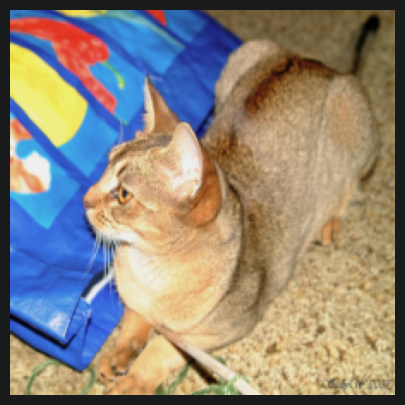

In [11]:
plot_img(train_dataset[7][0])

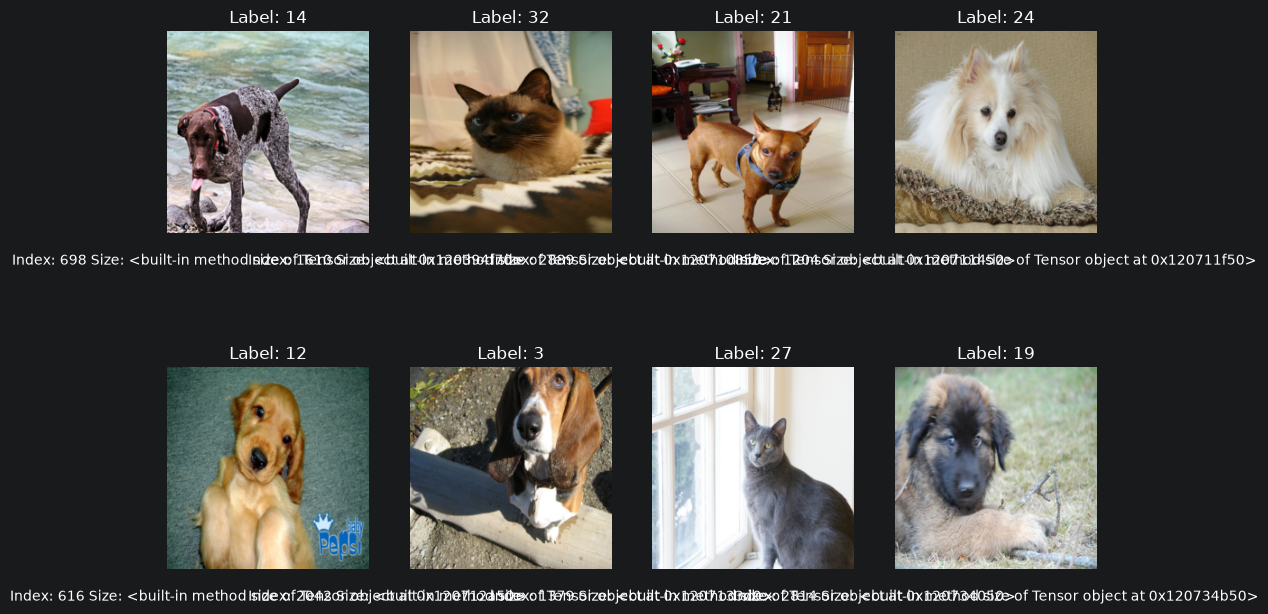

In [12]:
visual_exploration(train_dataset)

In [13]:
train_split = random_split(train_dataset,
                     [0.7, 0.3],
                     generator=torch.Generator().manual_seed(seed))
train_loader = DataLoader(train_split[0], batch_size=batch_size, shuffle=True)
val_loader = DataLoader(train_split[1], batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [14]:
for batch_idx, (features, labels) in enumerate(train_loader):
    # Move tensors to the correct device (GPU/CPU)
    features = features
    labels = labels

    # Your training or evaluation code here
    print(f"Batch {batch_idx} - Features shape: {features.shape}, Labels shape: {labels.shape}")

Batch 0 - Features shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])
Batch 1 - Features shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])
Batch 2 - Features shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])
Batch 3 - Features shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])
Batch 4 - Features shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])
Batch 5 - Features shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])
Batch 6 - Features shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])
Batch 7 - Features shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])
Batch 8 - Features shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])
Batch 9 - Features shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])
Batch 10 - Features shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])
Batch 11 - Features shape: torc